# MERIDIAN - Analysis Module 4: RFM Customer Segmentation

## Business question
Not all customers are equal, and treating them the same wastes marketing budget. This notebook scores every customer on three dimensions and groups them into actionable segments:

- **Recency (R)** - how long ago was their last order? Recent = more engaged.
- **Frequency (F)** - how many orders have they placed, total? More orders = more loyal.
- **Monetary (M)** - how much have they spent, total? More spend = more valuable.

Each customer gets a 1-5 score on each dimension, and the combination determines which segment they fall into - from 'Champions' (recent, frequent, high spend) down to 'Lost' (haven't bought in a long time, never bought much anyway).

## A design decision carried over from Module 3
Recency can't be measured against today's date - UCI's last order is from 2011, while the synthetic regions run through 2025. Comparing them against one global 'today' would make every UK customer look permanently inactive, regardless of how they actually behaved within their own era. Recency here is measured against **each region's own most recent order date**, not a single global reference point - the same fix applied in Module 3's Step 6, reused here for the same reason.

## Step 1 - Connect and load customer-level order history

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pyodbc

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()
orders = pd.read_sql("SELECT order_id, customer_id, region, order_date, amount_usd FROM marts.fct_orders", engine)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders = orders.dropna(subset=['customer_id', 'order_date', 'amount_usd'])
print(f"{len(orders):,} orders with a valid customer, date, and amount")

149,593 orders with a valid customer, date, and amount


## Step 2 - Aggregate to one row per customer

Collapse every customer's full order history down to the three numbers RFM actually needs.

In [9]:
customer_stats = orders.groupby(['customer_id', 'region']).agg(
    last_order_date=('order_date', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('amount_usd', 'sum'),
).reset_index()

print(f"{len(customer_stats):,} unique customers")
customer_stats.head()

103,130 unique customers


,customer_id,region,last_order_date,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,BR,2018-05-10 10:56:27,1,27.443549
1,0000b849f77a49e4a4ce2b2a4ca5be3f,BR,2018-05-07 11:11:27,1,5.258563
2,0000f46a3911fa3c0805444483337064,BR,2017-03-10 21:05:03,1,16.675002
3,0000f6ccb0745a6a4b88665a16c9f078,BR,2017-10-12 20:29:41,1,8.436135
4,0004aac84e0df4da2b147fca70cf8255,BR,2017-11-14 19:45:42,1,38.078650


## Step 3 - Recency, measured per-region (see design note above)

In [10]:
reference_date = orders.groupby('region')['order_date'].max() + pd.Timedelta(days=1)
customer_stats = customer_stats.join(reference_date.rename('reference_date'), on='region')
customer_stats['recency_days'] = (customer_stats['reference_date'] - customer_stats['last_order_date']).dt.days

customer_stats[['region', 'last_order_date', 'reference_date', 'recency_days']].head()

,region,last_order_date,reference_date,recency_days
0,BR,2018-05-10 10:56:27,2018-09-04 09:06:57,116
1,BR,2018-05-07 11:11:27,2018-09-04 09:06:57,119
2,BR,2017-03-10 21:05:03,2018-09-04 09:06:57,542
3,BR,2017-10-12 20:29:41,2018-09-04 09:06:57,326
4,BR,2017-11-14 19:45:42,2018-09-04 09:06:57,293


## Step 4 - Score each customer 1-5 on R, F, and M

Scoring is done **within each region separately** - the same reasoning as recency: a 'high spender' in Ghana and a 'high spender' in the UK aren't comparable in absolute dollar terms given very different regional scales, so each customer is scored relative to others in their own region.

**A technical note worth keeping:** naive quantile scoring (`pd.qcut`) breaks when many customers share the exact same value - which is expected here, since most customers in every region have `frequency = 1`. The fix below ranks customers first (breaking ties in a stable, deterministic way) before scoring, which avoids errors without changing the overall result. Tested against this exact scenario before running on the real data (see PROJECT_LOG.md).

In [11]:
def safe_qcut_score(series, ascending=True):
    ranks = series.rank(method='first')
    labels = [1,2,3,4,5] if ascending else [5,4,3,2,1]
    return pd.qcut(ranks, 5, labels=labels).astype(int)

customer_stats['R_score'] = customer_stats.groupby('region')['recency_days'].transform(
    lambda s: safe_qcut_score(s, ascending=False))  # fewer days since last order = higher score
customer_stats['F_score'] = customer_stats.groupby('region')['frequency'].transform(
    lambda s: safe_qcut_score(s, ascending=True))
customer_stats['M_score'] = customer_stats.groupby('region')['monetary'].transform(
    lambda s: safe_qcut_score(s, ascending=True))

customer_stats[['region', 'recency_days', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score']].head(10)

,region,recency_days,frequency,monetary,R_score,F_score,M_score
0,BR,116,1,27.443549,4,1,4
1,BR,119,1,5.258563,4,1,1
2,BR,542,1,16.675002,1,1,2
3,BR,326,1,8.436135,2,1,1
4,BR,293,1,38.078650,2,1,4
5,BR,151,1,32.294037,4,1,4
6,BR,136,1,6.842514,4,1,1
7,BR,187,1,81.069676,3,1,5
8,BR,548,1,29.033302,1,1,4
9,BR,175,1,25.095666,4,1,3


## Step 5 - Turn scores into named, actionable segments

This is one reasonable, documented rule set among several standard approaches - simple enough to explain in an interview, not a black box:

| Segment | Rule | What it means |
|---|---|---|
| Champions | R>=4, F>=4, M>=4 | Recent, frequent, big spenders - your best customers |
| Loyal Customers | F>=4 (not already Champions) | Buy often, may not be recent or big spenders |
| New Customers | R>=4, F<=2 | Recently active, but little order history yet |
| At Risk | R<=2, F>=3 | Used to buy often, haven't been back recently |
| Lost | R<=2, F<=2 | Inactive, and never ordered much to begin with |
| Needs Attention | everything else | Middling on every dimension |

In [12]:
def segment_name(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if f >= 4:
        return 'Loyal Customers'
    if r >= 4 and f <= 2:
        return 'New Customers'
    if r <= 2 and f >= 3:
        return 'At Risk'
    if r <= 2 and f <= 2:
        return 'Lost'
    return 'Needs Attention'

customer_stats['segment'] = customer_stats.apply(segment_name, axis=1)
customer_stats['segment'].value_counts()

segment
Loyal Customers    33035
Needs Attention    20435
Lost               17286
New Customers      15932
At Risk             8224
Champions           8218
Name: count, dtype: int64

## Step 6 - Visualize segment sizes, overall and by region

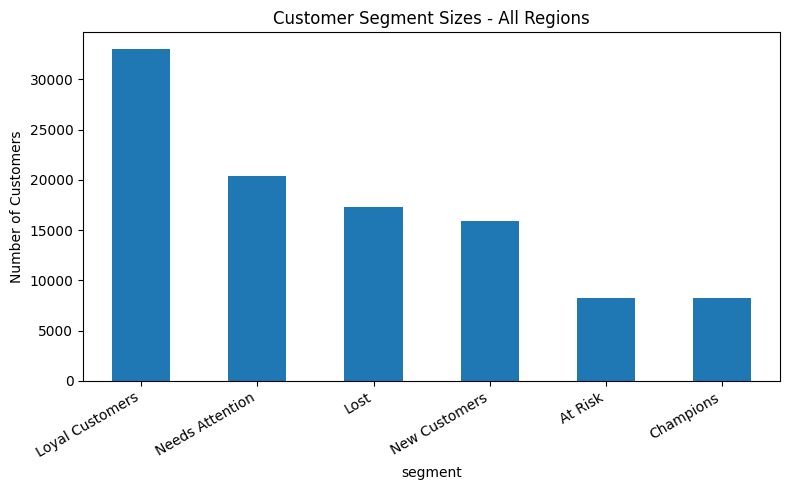

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
order = customer_stats['segment'].value_counts().index
customer_stats['segment'].value_counts().loc[order].plot(kind='bar', ax=ax)
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Segment Sizes - All Regions')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('rfm_segment_sizes.png', dpi=120)
plt.show()

In [14]:
segment_by_region = pd.crosstab(customer_stats['region'], customer_stats['segment'], normalize='index') * 100
segment_by_region.round(1)

segment,At Risk,Champions,Lost,Loyal Customers,Needs Attention,New Customers
region,,,,,,
BR,8.0,6.9,16.1,33.1,19.9,16.0
DE,6.1,15.1,23.4,25.0,19.2,11.2
GH,7.8,18.6,23.8,21.5,17.7,10.6
UK,7.9,21.9,25.8,18.1,18.6,7.7
US,9.5,16.7,23.3,23.3,16.4,10.7


## Step 7 - What to actually do about each segment

- **Champions** - reward them (loyalty perks, early access). They're already sold; the goal is retention, not persuasion.
- **Loyal Customers** - upsell/cross-sell opportunities; they trust the brand but may not be spending at their full potential yet.
- **New Customers** - focus on onboarding and a strong second-purchase incentive; the first 90 days determine whether they become Loyal or Lost.
- **At Risk** - the highest-value recovery target: win-back campaigns, personalized discounts, or a direct check-in. They've already proven they'll spend; something changed.
- **Lost** - lowest priority for marketing spend; a low-cost reactivation email is reasonable, but heavy investment here has the weakest expected return.
- **Needs Attention** - broad, general engagement (newsletters, seasonal promotions) rather than a targeted campaign.

## Findings - fill this in with your actual numbers

_After running the cells above: which segment is largest, overall and per region? Does any region have a notably different segment mix than the others (e.g. given Brazil's 3.1% repeat-purchase rate from Module 3, expect very few Champions/Loyal Customers there). Write 2-3 sentences, then carry into `PROJECT_LOG.md`._

## Known limitation - worth stating explicitly
In regions where almost every customer has `frequency = 1` (Brazil, per Module 3's finding), the F score becomes close to arbitrary - `pd.qcut` still divides tied customers into 5 groups to keep the pipeline from erroring out, but there's little real behavioral difference between an F score of 1 and 5 when nearly everyone ordered exactly once. Segment labels for Brazil should be read with that caveat in mind.

## Step 8 - Export results to SQL Server for Power BI

Writes the customer-level RFM results to `reporting.rfm_results`, so the dashboard can pull segment data directly from SQL Server instead of needing this notebook re-run every time.

In [15]:
export_df = customer_stats[['customer_id', 'region', 'recency_days', 'frequency',
                             'monetary', 'R_score', 'F_score', 'M_score', 'segment']].copy()
export_df.to_sql('rfm_results', engine, schema='reporting', if_exists='replace', index=False)
print(f"Exported {len(export_df):,} customer RFM results to reporting.rfm_results")

Exported 103,130 customer RFM results to reporting.rfm_results
